# Cyber Threat Detection - Exploratory Data Analysis (EDA)

# Imports and Environment Setup

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn


# Dataset Loading

In [19]:
df = pd.read_csv("../data/cybersecurity.csv")
df.head()

,timestamp,src_ip,dst_ip,src_port,dst_port,protocol,bytes_sent,bytes_received,user_agent,url,is_internal_traffic,label,attack_type
0,2025-10-01 00:12:54,188.176.27.165,253.240.113.218,56377,445,TCP,8029,17204,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://webmail.corp/login?id=385071,False,0,benign
1,2025-10-01 00:23:43,68.59.26.43,212.75.38.111,51165,1433,TCP,676368,2643374,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://portal.example.org/owa/auth/logon.aspx...,False,0,benign
2,2025-10-01 00:25:46,119.204.243.78,90.28.90.234,14948,1433,TCP,316502,38571,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,NaN,False,0,benign
3,2025-10-01 00:27:21,122.119.194.175,175.140.78.230,36097,443,TCP,70933,21935,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://webmail.corp/phpmyadmin?id=114701,False,0,benign
4,2025-10-01 00:40:09,181.199.242.68,55.99.177.69,445,21255,TCP,12721,9939,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://portal.example.org/config.php?id=345569,False,0,benign


# Dataset Overview

In [20]:
df.shape

(10000, 13)

In [21]:
df.columns

Index(['timestamp', 'src_ip', 'dst_ip', 'src_port', 'dst_port', 'protocol',
       'bytes_sent', 'bytes_received', 'user_agent', 'url',
       'is_internal_traffic', 'label', 'attack_type'],
      dtype='object')

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   timestamp            10000 non-null  object
 1   src_ip               10000 non-null  object
 2   dst_ip               10000 non-null  object
 3   src_port             10000 non-null  int64 
 4   dst_port             10000 non-null  int64 
 5   protocol             10000 non-null  object
 6   bytes_sent           10000 non-null  int64 
 7   bytes_received       10000 non-null  int64 
 8   user_agent           10000 non-null  object
 9   url                  6768 non-null   object
 10  is_internal_traffic  10000 non-null  bool  
 11  label                10000 non-null  int64 
 12  attack_type          10000 non-null  object
dtypes: bool(1), int64(5), object(7)
memory usage: 947.4+ KB


# Missing Value Analysis

In [23]:
df.isnull().sum()

timestamp                 0
src_ip                    0
dst_ip                    0
src_port                  0
dst_port                  0
protocol                  0
bytes_sent                0
bytes_received            0
user_agent                0
url                    3232
is_internal_traffic       0
label                     0
attack_type               0
dtype: int64

# Attack Type Distribution

In [24]:
df['attack_type'].value_counts()

attack_type
benign                 9600
brute-force             108
port-scan                81
sql-injection            64
xss                      34
credential-stuffing      28
ddos                     27
command-injection        26
exploit-attempt          22
c2                       10
Name: count, dtype: int64

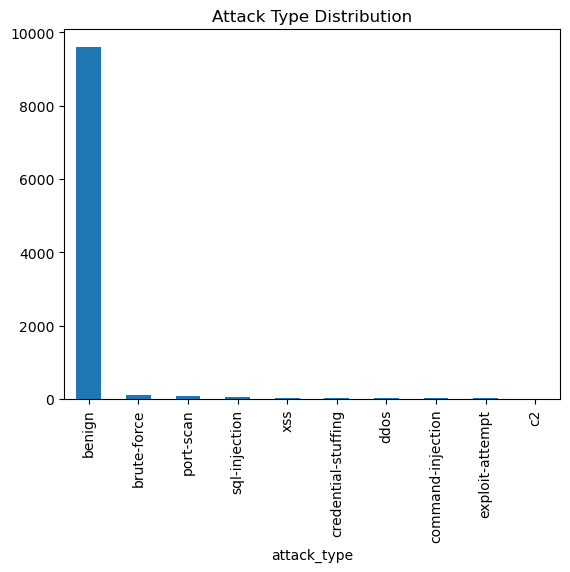

In [25]:
import matplotlib.pyplot as plt

df['attack_type'].value_counts().plot(kind='bar')

plt.title("Attack Type Distribution")

plt.show()

Veri kümesi oldukça dengesizdir; zararsız trafik örneklerinin sayısı, kötü niyetli trafik örneklerinin sayısını önemli ölçüde aşmaktadır. Bu durum, genel trafik hacminin büyük bir kısmını normal ağ faaliyetlerinin oluşturduğu gerçek hayattaki SOC ortamlarını yansıtmaktadır. Ancak bu tür bir dengesizlik, tahminleri zararsız sınıfa yönlendirerek saldırı tespit performansını düşürmesi nedeniyle makine öğrenimi modellerini olumsuz etkileyebilir.


# URL-Based Traffic Analysis

In [26]:
df[df['url'].isnull()]['attack_type'].value_counts()

attack_type
benign                 3101
brute-force              33
port-scan                31
sql-injection            21
credential-stuffing      11
xss                      10
command-injection         9
ddos                      8
exploit-attempt           5
c2                        3
Name: count, dtype: int64

In [27]:
df[df['url'].notnull()]['attack_type'].value_counts()

attack_type
benign                 6499
brute-force              75
port-scan                50
sql-injection            43
xss                      24
ddos                     19
credential-stuffing      17
command-injection        17
exploit-attempt          17
c2                        7
Name: count, dtype: int64

# Protocol Analysis

In [28]:
df['protocol'].value_counts()

protocol
TCP     7765
UDP     1910
ICMP     325
Name: count, dtype: int64

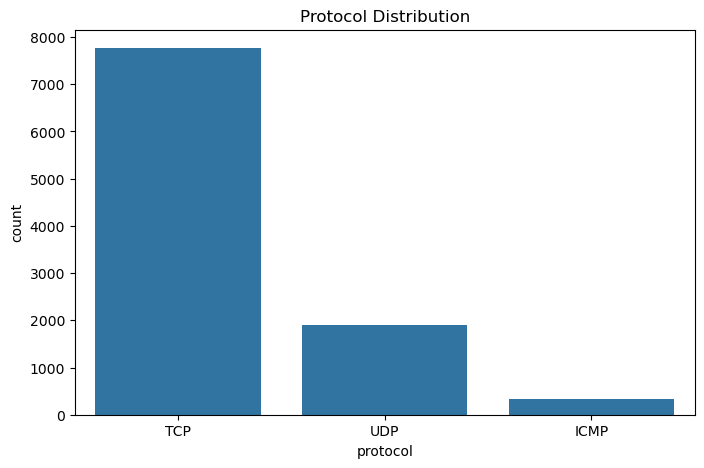

In [29]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='protocol')

plt.title("Protocol Distribution")

plt.show()

Bu grafik ağ trafiğinde kullanılan protokollerin dağılımını göstermektedir. TCP protokolünün yüksek olması gerçek SOC ortamlarında normal bir durumdur çünkü web trafiği, HTTPS ve çoğu istemci-sunucu iletişimi TCP tabanlı çalışır. UDP trafiğinin yoğunluğu bazı durumlarda DDoS veya flood saldırılarının göstergesi olabilir. ICMP trafiği ise ağ erişilebilirliğini test etmek amacıyla normal kullanılabilse de yüksek yoğunluklu ICMP trafiği olası ICMP flood davranışına işaret edebilir.

# Attack Type vs Protocol Analysis

In [30]:
pd.crosstab(df['attack_type'], df['protocol'])

protocol,ICMP,TCP,UDP
attack_type,,,
benign,307,7451,1842
brute-force,3,85,20
c2,1,7,2
command-injection,0,23,3
credential-stuffing,0,23,5
ddos,3,17,7
exploit-attempt,0,18,4
port-scan,2,63,16
sql-injection,8,49,7


Bu analiz saldırı türleri ile kullanılan ağ protokolleri arasındaki ilişkiyi göstermektedir. Tüm saldırı türlerinde TCP protokolünün baskın olduğu görülmektedir. Bu durum özellikle SQL injection, XSS, brute-force ve credential stuffing gibi web uygulaması ve kimlik doğrulama tabanlı saldırıların TCP üzerinden çalışan HTTP, HTTPS, SSH ve RDP servislerini hedeflemesiyle uyumludur. Port scanning saldırılarında da TCP kullanımının yüksek olması saldırganların açık servis ve port keşfi gerçekleştirdiğini gösterebilir. DDoS saldırılarında UDP kullanımının beklenenden düşük olması ise veri setindeki DDoS aktivitelerinin ağırlıklı olarak TCP tabanlı gerçekleşmiş olabileceğini düşündürmektedir.

# Destination Port Analysis

In [31]:
df['dst_port'].value_counts().head(15)

dst_port
80       1013
443      1009
1433      965
3306      965
22        960
25        947
21        938
53        934
3389      919
445       905
368         2
231         2
18283       2
758         2
628         2
Name: count, dtype: int64

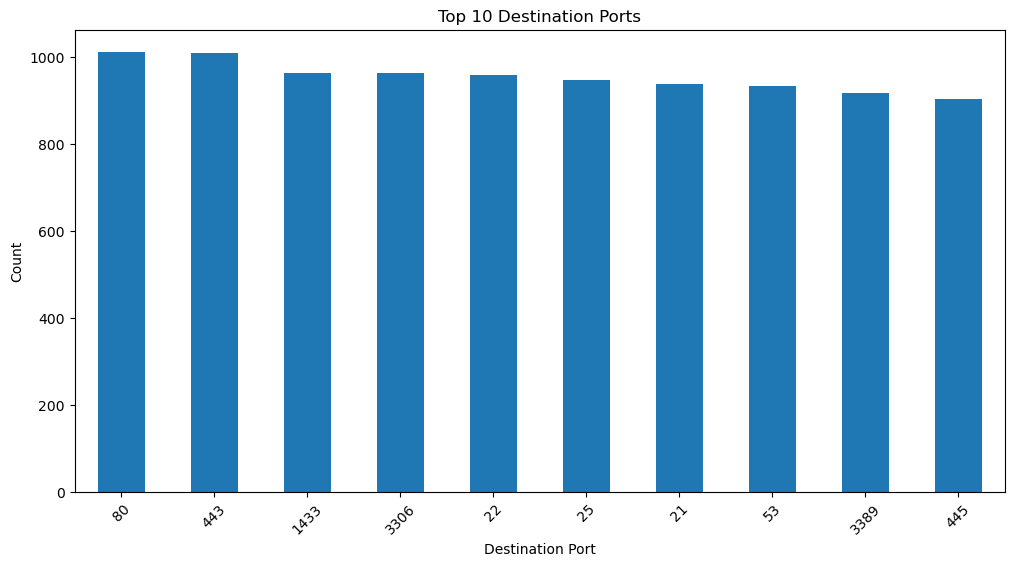

In [32]:
plt.figure(figsize=(12,6))

df['dst_port'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Destination Ports")

plt.xlabel("Destination Port")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

Bu grafik veri setinde en sık hedeflenen destination portlarını göstermektedir. 80 (HTTP) ve 443 (HTTPS) portlarının yüksek olması web trafiğinin modern ağ iletişiminin temelini oluşturmasıyla ilişkilidir. Bu servislerin dünya genelinde sürekli erişilebilir olması saldırganlar için geniş bir saldırı yüzeyi oluşturmaktadır. Ayrıca web servisleri kullanıcı verileri, oturum bilgileri ve uygulama altyapılarına erişim sağladığı için saldırganlar tarafından sık hedef alınmaktadır. Bunun yanında 22 (SSH), 3389 (RDP), 445 (SMB) ve 1433 (MSSQL) gibi kritik servis portlarının yüksek görünmesi veri setinin yalnızca web saldırılarını değil aynı zamanda uzaktan erişim, ağ paylaşımı ve veritabanı hedefli saldırıları da içerdiğini göstermektedir.

# Attack Type vs Destination Port Analysis

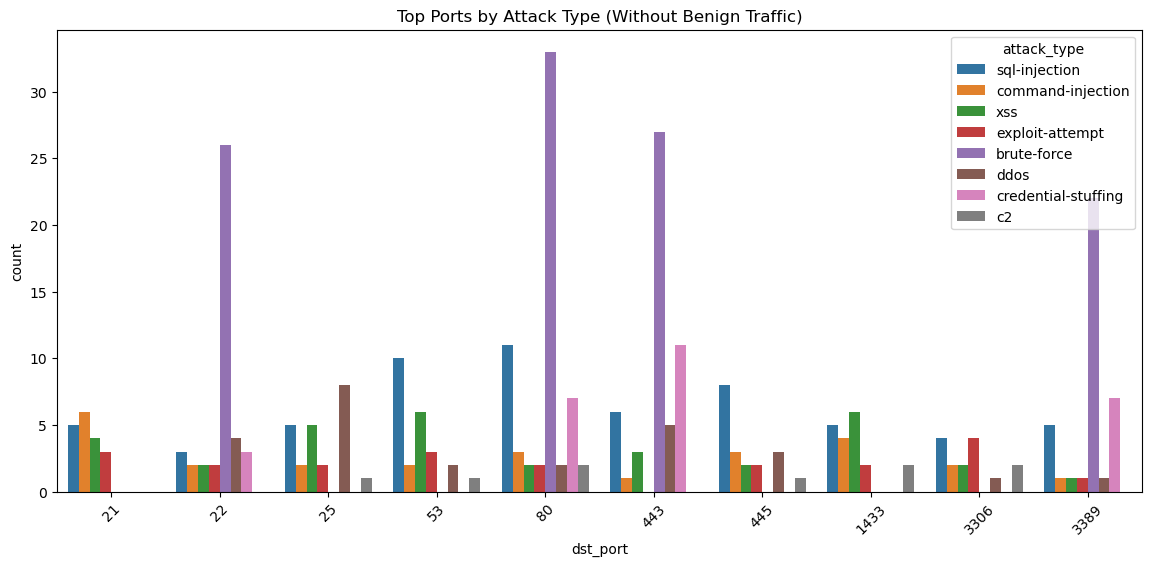

In [35]:
top_ports = df['dst_port'].value_counts().head(10).index

filtered_ports = df[
    df['dst_port'].isin(top_ports)
]

attack_df = filtered_ports[
    filtered_ports['attack_type'] != 'benign'
]

plt.figure(figsize=(14,6))

sns.countplot(data=attack_df,
              x='dst_port',
              hue='attack_type')

plt.title("Top Ports by Attack Type (Without Benign Traffic)")

plt.xticks(rotation=45)

plt.show()

Bu analiz saldırı türlerinin hedeflediği servis portlarını göstermektedir. Brute-force saldırılarının özellikle 22 (SSH), 3389 (RDP), 80 (HTTP) ve 443 (HTTPS) portlarında yoğunlaştığı görülmektedir. Bu durum saldırganların uzaktan erişim servisleri ve web tabanlı kimlik doğrulama sistemlerini hedef aldığını düşündürmektedir. SQL injection ve XSS saldırılarının ağırlıklı olarak 80 ve 443 portlarında görülmesi bu saldırıların web uygulamaları üzerinden gerçekleştirildiği davranışıyla uyumludur. Ayrıca C2 aktivitelerinin HTTP/HTTPS portlarında görülmesi zararlı yazılımların normal web trafiğine benzemeye çalışabileceğini göstermektedir.

# Traffic Volume Analysis

In [38]:
df['bytes_sent_mb'] = df['bytes_sent'] / (1024 * 1024)

df['bytes_sent_mb'].describe()

count    10000.000000
mean         0.134713
std          2.029552
min          0.000016
25%          0.006817
50%          0.020805
75%          0.062080
max        132.723241
Name: bytes_sent_mb, dtype: float64

Bytes_sent analizinde veri dağılımının dengesiz olduğu görülmektedir. Ortalama veri transfer miktarı yaklaşık 0.13 MB seviyesindeyken median değerin yaklaşık 0.02 MB olması ağ trafiğinin büyük kısmının düşük boyutlu veri transferlerinden oluştuğunu göstermektedir. Buna rağmen maksimum veri transfer miktarının yaklaşık 132 MB seviyesine ulaşması veri setinde belirgin aykırı değerler (outlier) bulunduğunu göstermektedir. Bu durum büyük ölçekli dosya transferleri, veri sızdırma (data exfiltration) aktiviteleri veya anormal ağ davranışlarıyla ilişkili olabilir. Ayrıca ortalama değerin median değerden yüksek olması veri dağılımının sağa çarpık (right-skewed) bir yapıya sahip olduğunu göstermektedir.

# Raw Traffic Distribution

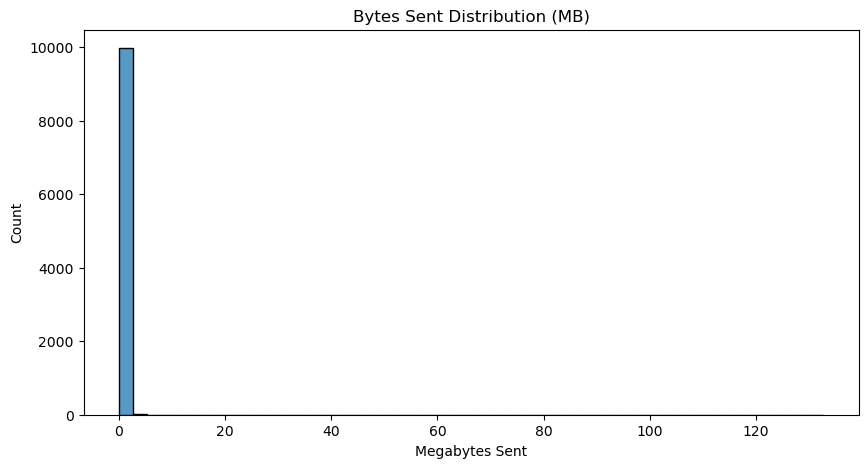

In [39]:
plt.figure(figsize=(10,5))

sns.histplot(df['bytes_sent_mb'],
             bins=50)

plt.title("Bytes Sent Distribution (MB)")

plt.xlabel("Megabytes Sent")
plt.ylabel("Count")

plt.show()

Ham veri dağılımı görselleştirildiğinde aykırı değerlerin (outlier) histogramı baskıladığı görülmektedir. Bu durum veri dağılımının yüksek derecede sağa çarpık olduğunu göstermektedir. Daha okunabilir bir dağılım elde etmek için log transformation uygulanacaktır.

# Filtered Traffic Distribution

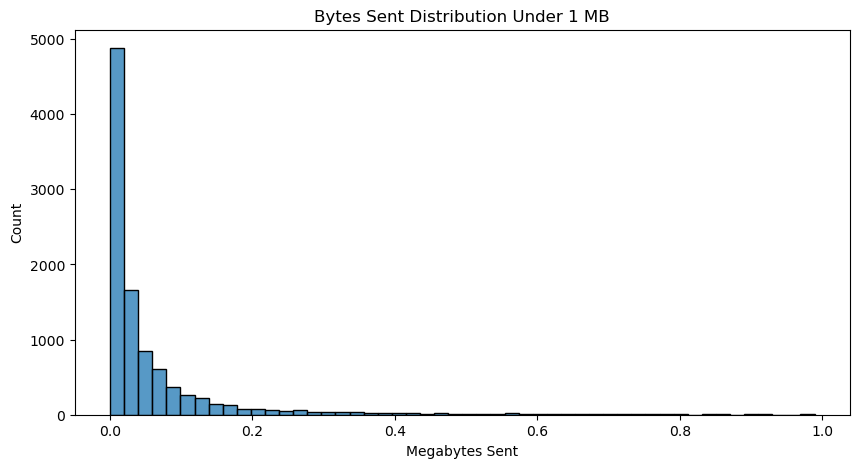

In [41]:
filtered_mb = df[
    df['bytes_sent_mb'] < 1
]

plt.figure(figsize=(10,5))

sns.histplot(filtered_mb['bytes_sent_mb'],
             bins=50)

plt.title("Bytes Sent Distribution Under 1 MB")

plt.xlabel("Megabytes Sent")
plt.ylabel("Count")

plt.show()

1 MB altındaki veri transferleri incelendiğinde ağ trafiğinin büyük bölümünün düşük boyutlu veri iletimlerinden oluştuğu görülmektedir. Veri dağılımının sağa çarpık yapıda olması az sayıda yüksek boyutlu veri transferinin bulunduğunu göstermektedir. Bu durum gerçek ağ ortamlarında normal kullanıcı aktivitelerinin çoğunlukla küçük veri paketleriyle gerçekleşmesiyle uyumludur. Sağ tarafta görülen uzun kuyruk yapısı ise büyük dosya transferleri, yedekleme işlemleri veya anormal veri aktarım aktiviteleriyle ilişkili olabilir.

# Attack Type vs Traffic Volume

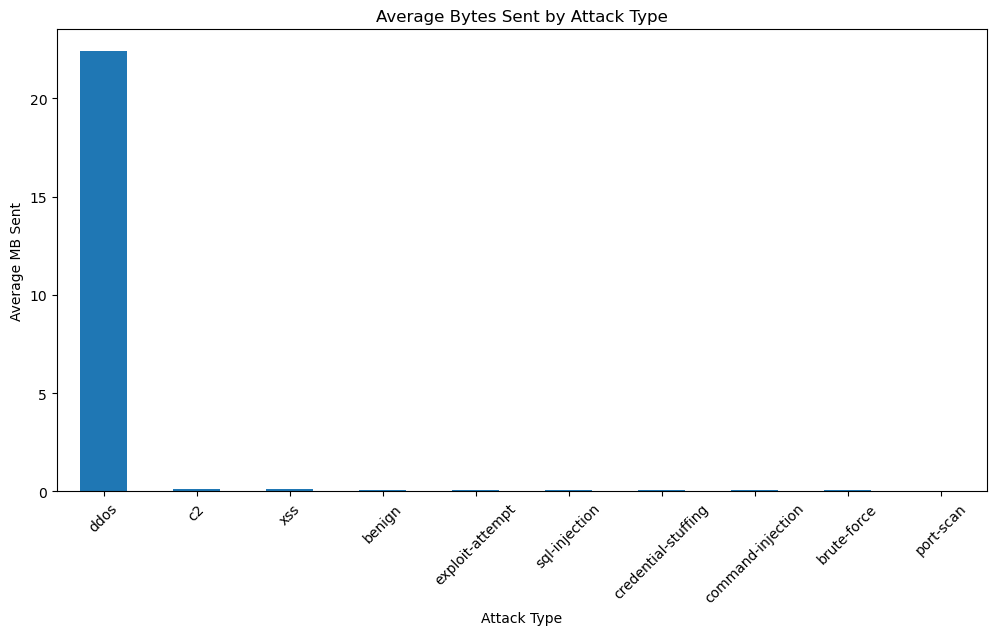

In [45]:
attack_avg = df.groupby('attack_type')['bytes_sent_mb'].mean()

attack_avg = attack_avg.sort_values(ascending=False)

plt.figure(figsize=(12,6))

attack_avg.plot(kind='bar')

plt.title("Average Bytes Sent by Attack Type")

plt.xlabel("Attack Type")
plt.ylabel("Average MB Sent")

plt.xticks(rotation=45)

plt.show()

Saldırı türlerine göre ortalama veri transfer miktarı incelendiğinde DDoS saldırılarının diğer saldırı türlerine kıyasla belirgin şekilde daha yüksek trafik ürettiği görülmektedir. Bu durum DDoS saldırılarının hedef sistem kaynaklarını tüketmeye yönelik yüksek hacimli ağ trafiği oluşturma davranışıyla uyumludur. Brute-force, SQL injection, XSS ve credential stuffing gibi saldırı türlerinin ise daha düşük veri transfer miktarlarına sahip olduğu görülmektedir. Bu saldırılar genellikle küçük boyutlu fakat tekrarlayan isteklerle gerçekleştirildiği için düşük trafik üretmeleri beklenen bir davranıştır. Ayrıca C2 aktivitelerinin diğer bazı saldırı türlerine kıyasla daha yüksek veri transferine sahip olması zararlı yazılım iletişimi veya veri aktarımı davranışlarıyla ilişkili olabilir.

# Correlation Analysis

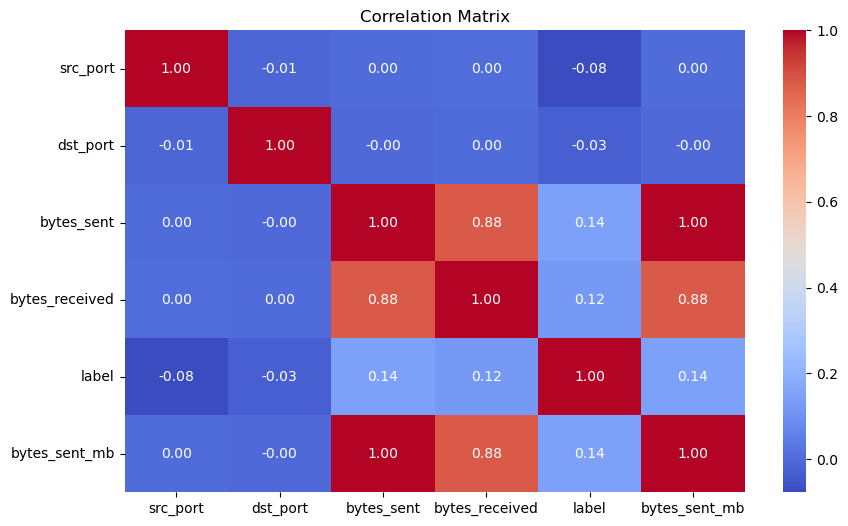

In [46]:
numeric_df = df.select_dtypes(include=np.number)

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(10,6))

sns.heatmap(correlation_matrix,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title("Correlation Matrix")

plt.show()

Correlation analizi incelendiğinde bytes_sent ve bytes_received özellikleri arasında güçlü bir pozitif ilişki bulunduğu görülmektedir. Bu durum yüksek veri gönderimi gerçekleştiren bağlantıların genellikle yüksek veri alımı da gerçekleştirdiğini göstermektedir. Label ile diğer özellikler arasındaki korelasyon değerlerinin düşük olması saldırı davranışlarının tek bir özellik üzerinden belirlenemeyeceğini ve çoklu davranış kombinasyonlarıyla değerlendirilmesi gerektiğini göstermektedir. Ayrıca bytes_sent ve bytes_sent_mb özellikleri arasında 1.00 korelasyon bulunması bu iki özelliğin aynı veriyi farklı ölçekte temsil ettiğini göstermektedir. Bu nedenle makine öğrenmesi aşamasında redundant feature olarak değerlendirilerek birinin çıkarılması düşünülebilir.

# Final Security Insights

Bu EDA çalışması sonucunda saldırı türleri, ağ protokolleri, hedef portlar ve trafik davranışları arasında çeşitli ilişkiler gözlemlenmiştir. Özellikle DDoS saldırılarının yüksek trafik üretmesi, brute-force saldırılarının SSH ve RDP servislerinde yoğunlaşması ve web tabanlı saldırıların HTTP/HTTPS servislerini hedeflemesi dikkat çekmiştir. Ayrıca veri dağılımındaki aykırı değerler ve feature ilişkileri incelenerek makine öğrenmesi aşaması için önemli ön bilgiler elde edilmiştir.